In [ ]:
import pandas as pd
import seaborn as sns


In [18]:
import torch

if torch.cuda.is_available():
    print(f"GPU activated: {torch.cuda.get_device_name(0)}")
else:
    print(" still CPU")

 still CPU


In [19]:
%cd /content/Walmart_sales_forecasting
save_file = "data/processed/sales_data_preprocessed.csv"


df_sales = pd.read_csv(save_file, parse_dates=['Date'])
df_sales

/content/Walmart_sales_forecasting


,Store,Dept,Date,Weekly_Sales,IsHoliday,Type,Size,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment
0,1,1,2010-02-05,24924.50,False,A,151315,42.31,2.572,0.00,0.00,0.00,0.00,0.00,211.096358,8.106
1,1,1,2010-02-12,46039.49,True,A,151315,38.51,2.548,0.00,0.00,0.00,0.00,0.00,211.242170,8.106
2,1,1,2010-02-19,41595.55,False,A,151315,39.93,2.514,0.00,0.00,0.00,0.00,0.00,211.289143,8.106
3,1,1,2010-02-26,19403.54,False,A,151315,46.63,2.561,0.00,0.00,0.00,0.00,0.00,211.319643,8.106
4,1,1,2010-03-05,21827.90,False,A,151315,46.50,2.625,0.00,0.00,0.00,0.00,0.00,211.350143,8.106
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
421565,45,98,2012-09-28,508.37,False,B,118221,64.88,3.997,4556.61,20.64,1.50,1601.01,3288.25,192.013558,8.684
421566,45,98,2012-10-05,628.10,False,B,118221,64.89,3.985,5046.74,0.00,18.82,2253.43,2340.01,192.170412,8.667
421567,45,98,2012-10-12,1061.02,False,B,118221,54.47,4.000,1956.28,0.00,7.89,599.32,3990.54,192.327265,8.667
421568,45,98,2012-10-19,760.01,False,B,118221,56.47,3.969,2004.02,0.00,3.18,437.73,1537.49,192.330854,8.667


In [20]:
df_sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 421570 entries, 0 to 421569
Data columns (total 16 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   Store         421570 non-null  int64         
 1   Dept          421570 non-null  int64         
 2   Date          421570 non-null  datetime64[ns]
 3   Weekly_Sales  421570 non-null  float64       
 4   IsHoliday     421570 non-null  bool          
 5   Type          421570 non-null  object        
 6   Size          421570 non-null  int64         
 7   Temperature   421570 non-null  float64       
 8   Fuel_Price    421570 non-null  float64       
 9   MarkDown1     421570 non-null  float64       
 10  MarkDown2     421570 non-null  float64       
 11  MarkDown3     421570 non-null  float64       
 12  MarkDown4     421570 non-null  float64       
 13  MarkDown5     421570 non-null  float64       
 14  CPI           421570 non-null  float64       
 15  Unemployment  421

In [21]:
feature = ['Store', 'Date', 'Temperature', 'Fuel_Price', 'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5', 'CPI']
print('Basic Statistical Summary \n')
print('Sales Summary: \n')
print(df_sales['Weekly_Sales'].describe())
print('Feature Summary: \n')
print(df_sales[feature].describe())


print(f'Range of date: from {df_sales['Date'].min()} to {df_sales['Date'].max()}')
print(f'Stores: {df_sales['Store'].unique()[:30]}')
print(f'Departments: {df_sales['Dept'].unique()[:30]}')
print(f'Types: {df_sales['Type'].unique()}')


Basic Statistical Summary 

Sales Summary: 

count    421570.000000
mean      15981.258123
std       22711.183519
min       -4988.940000
25%        2079.650000
50%        7612.030000
75%       20205.852500
max      693099.360000
Name: Weekly_Sales, dtype: float64
Feature Summary: 

               Store                           Date    Temperature  \
count  421570.000000                         421570  421570.000000   
mean       22.200546  2011-06-18 08:30:31.963375104      60.090059   
min         1.000000            2010-02-05 00:00:00      -2.060000   
25%        11.000000            2010-10-08 00:00:00      46.680000   
50%        22.000000            2011-06-17 00:00:00      62.090000   
75%        33.000000            2012-02-24 00:00:00      74.280000   
max        45.000000            2012-10-26 00:00:00     100.140000   
std        12.785297                            NaN      18.447931   

          Fuel_Price      MarkDown1      MarkDown2      MarkDown3  \
count  421570.000

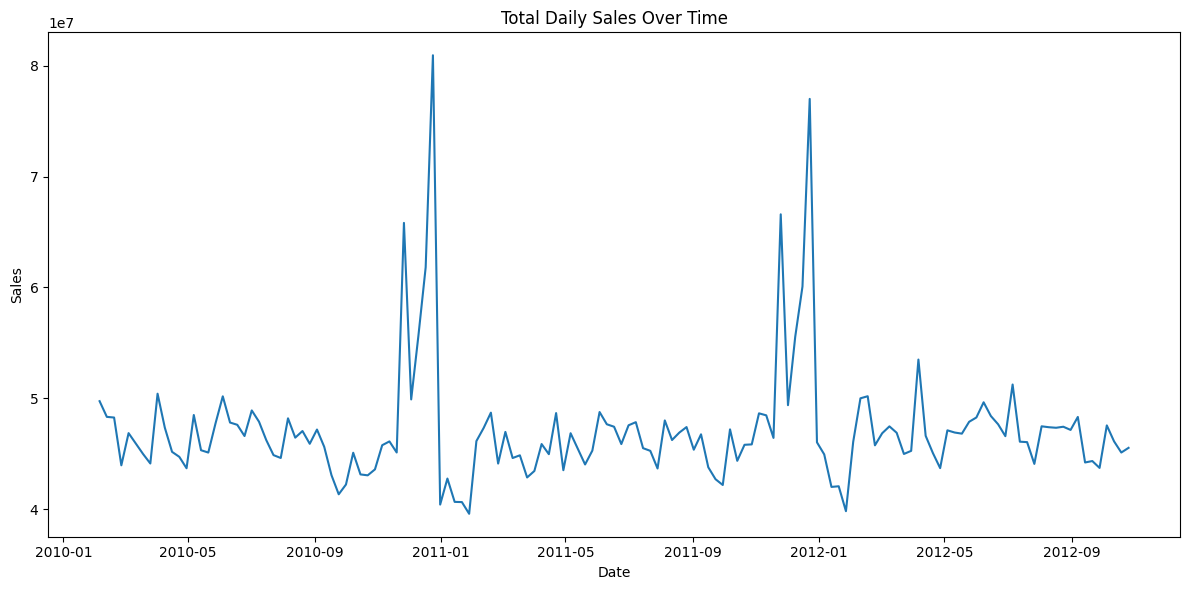

In [22]:
import matplotlib.pyplot as plt
import os

fig1, ax1 = plt.subplots(figsize=(12,6))
ax1.plot(df_sales.groupby('Date')['Weekly_Sales'].sum())
ax1.set_xlabel('Date')
ax1.set_ylabel('Sales')
ax1.set_title('Total Daily Sales Over Time')
fig1.tight_layout()

save_figure = True
os.makedirs("data/fig", exist_ok=True)
fig1_dir = 'data/fig/daily_sales_fig.png'
if save_figure:
    fig1.savefig(fig1_dir)


In [23]:
%cd /content/Walmart_sales_forecasting/data/fig/
!ls

/content/Walmart_sales_forecasting/data/fig
daily_sales_fig.png


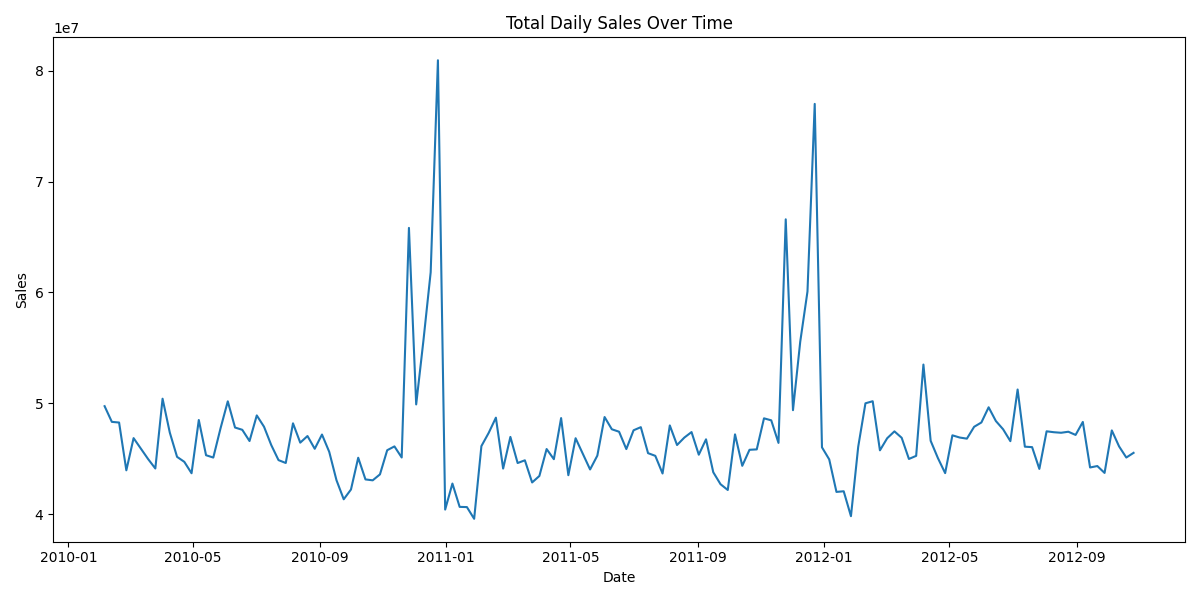

In [24]:
from IPython.display import Image
Image(filename='/content/Walmart_sales_forecasting/data/fig/daily_sales_fig.png')

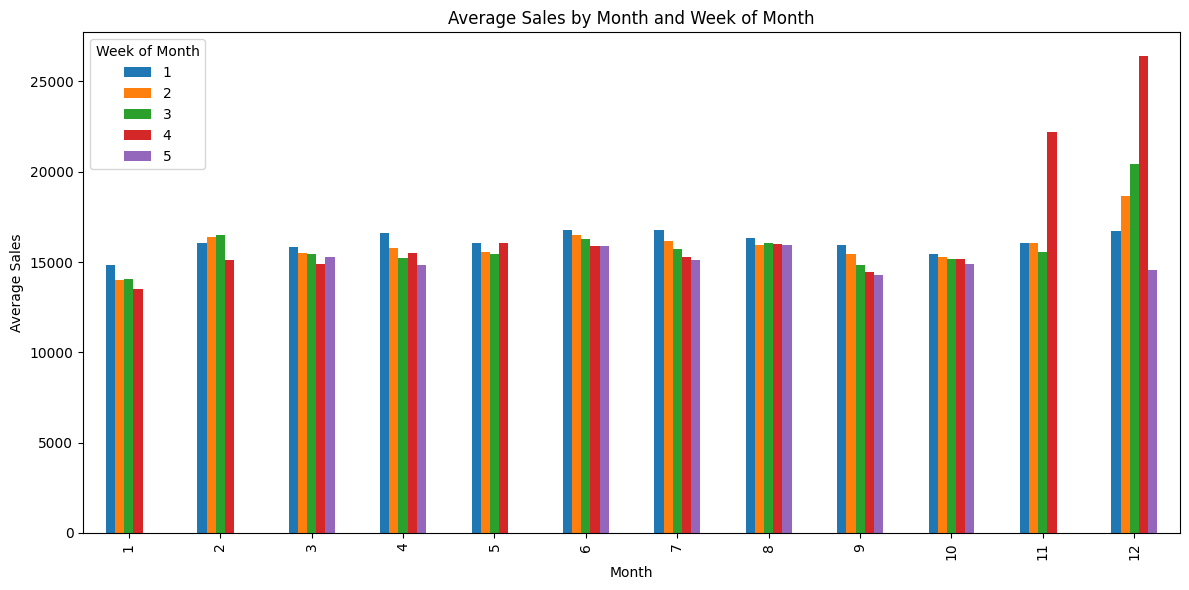

In [25]:
# Tính tuần trong tháng (bắt đầu từ 1)
df_sales['week_of_month'] = (df_sales['Date'].dt.day - 1) // 7 + 1
weekly_monthly_avg = df_sales.groupby('week_of_month')['Weekly_Sales'].mean()
df_sales['month'] = df_sales['Date'].dt.month
fig2, ax2 = plt.subplots(figsize=(12,6))
df_sales.groupby(['month', 'week_of_month'])['Weekly_Sales'].mean().unstack().plot(kind='bar', ax=ax2)
ax2.set_title('Average Sales by Month and Week of Month')
ax2.set_xlabel('Month')
ax2.set_ylabel('Average Sales')
ax2.legend(title='Week of Month')
fig2.tight_layout()


# save_figure = True
# os.makedirs("data/fig", exist_ok=True)
fig2_dir = 'avg_sales_by_week_of_month.png'
if save_figure:
    fig2.savefig(fig2_dir)
    



In [26]:
%cd /content/Walmart_sales_forecasting/data/fig/
!ls

/content/Walmart_sales_forecasting/data/fig
avg_sales_by_week_of_month.png	daily_sales_fig.png


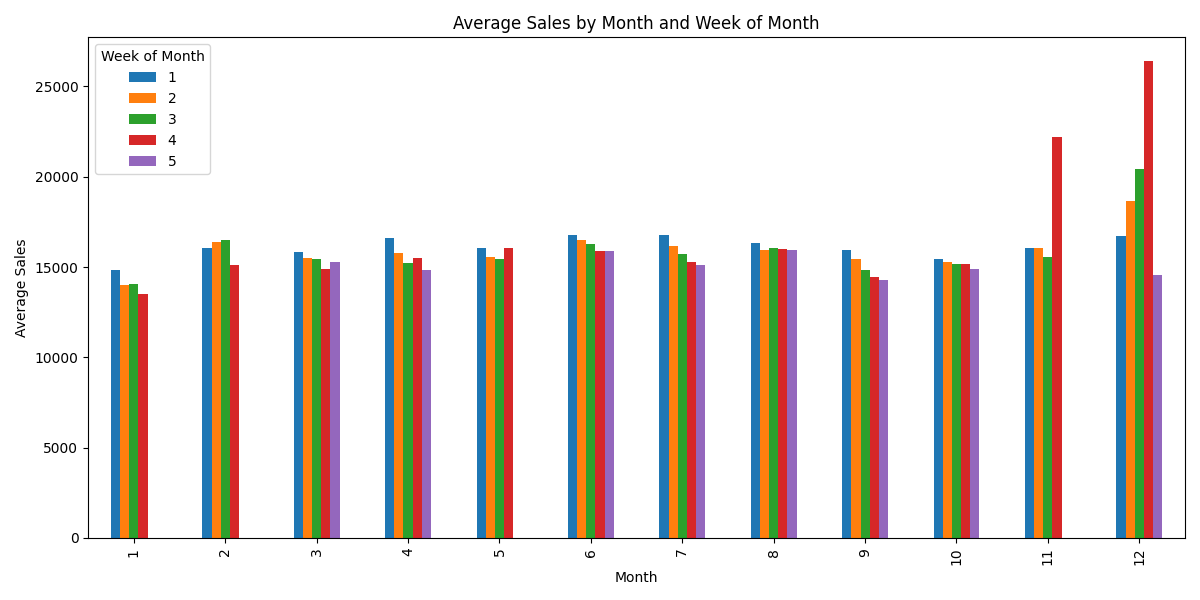

In [27]:
Image(filename='/content/Walmart_sales_forecasting/data/fig/avg_sales_by_week_of_month.png')

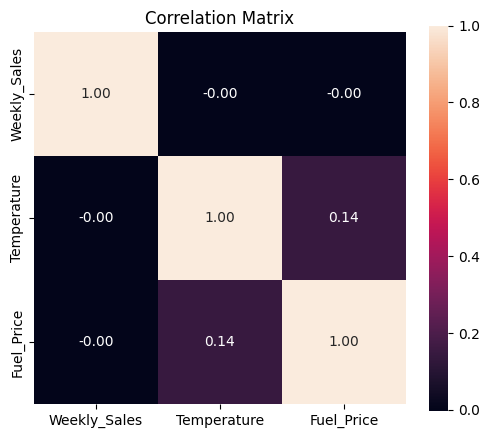

In [28]:
cols = ['Weekly_Sales', 'Temperature', 'Fuel_Price']
corr = df_sales[cols].corr()

fig3, ax3 = plt.subplots(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='rocket', square=True)
ax3.set_title('Correlation Matrix')

fig3_dir = 'temp_and_fuel_vs_sales.png'
if save_figure:
    fig3.savefig(fig3_dir)

In [29]:
%cd /content/Walmart_sales_forecasting/data/fig/
!ls

/content/Walmart_sales_forecasting/data/fig
avg_sales_by_week_of_month.png	daily_sales_fig.png  temp_and_fuel_vs_sales.png
